In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import joblib

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("C:\\Users\\sreer\\OneDrive\\Desktop\\Shopper_Spectrum\\online_retail.csv")

In [6]:
print(df.shape)

df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
df = df[df['Quantity'] > 0]

In [12]:
df = df[df['UnitPrice'] > 0]

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalPrice': 'sum'

}).reset_index()

In [16]:
rfm.columns = [

    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'

]

In [17]:
rfm.head()
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


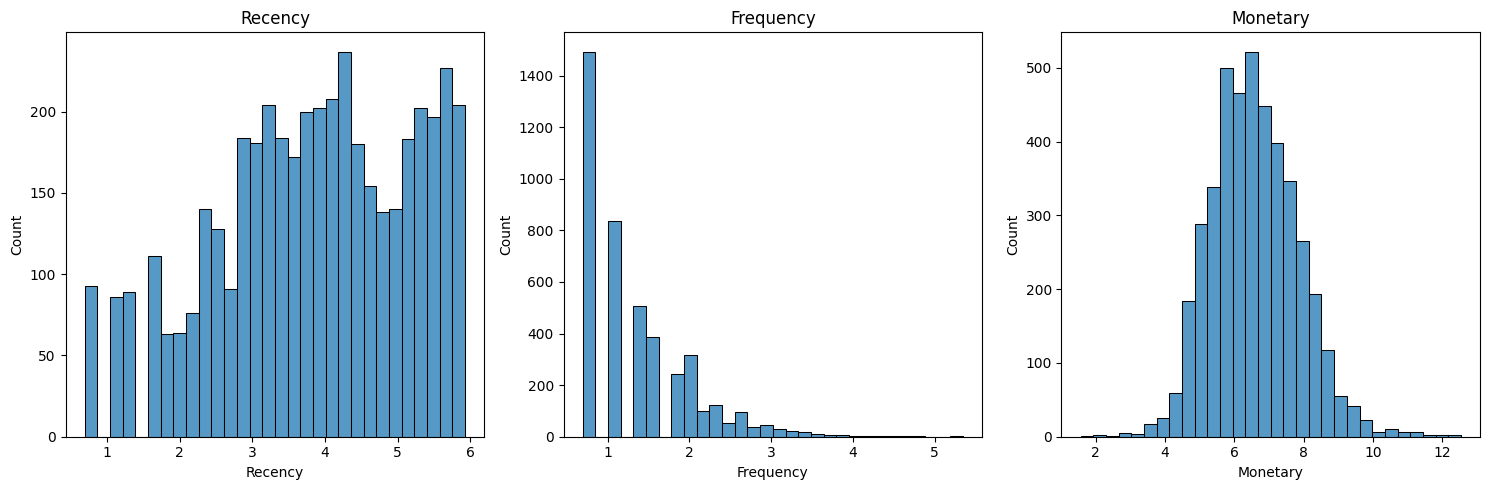

In [18]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.histplot(np.log1p(rfm['Recency']),
             bins=30,
             ax=axes[0])

axes[0].set_title("Recency")

sns.histplot(np.log1p(rfm['Frequency']),
             bins=30,
             ax=axes[1])

axes[1].set_title("Frequency")

sns.histplot(np.log1p(rfm['Monetary']),
             bins=30,
             ax=axes[2])

axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(

    rfm[['Recency',
         'Frequency',
         'Monetary']]

)

In [20]:
inertia = []

k_range = range(2,11)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

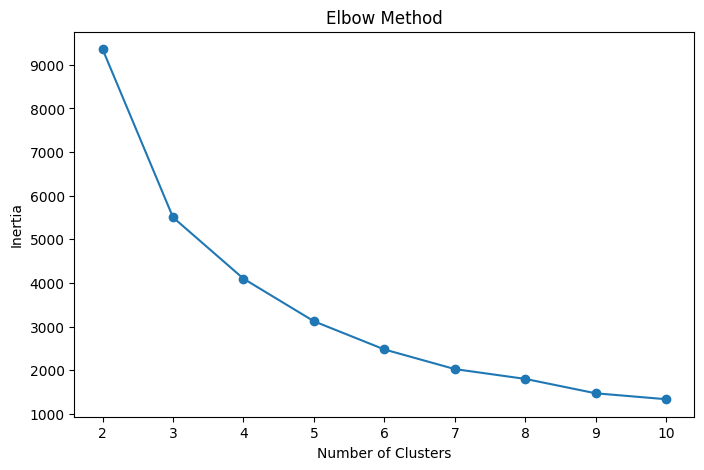

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [22]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K={k} : {score:.4f}"
    )

K=2 : 0.5604
K=3 : 0.5853
K=4 : 0.6162
K=5 : 0.6165
K=6 : 0.5983
K=7 : 0.5171
K=8 : 0.4912
K=9 : 0.4784
K=10 : 0.4448


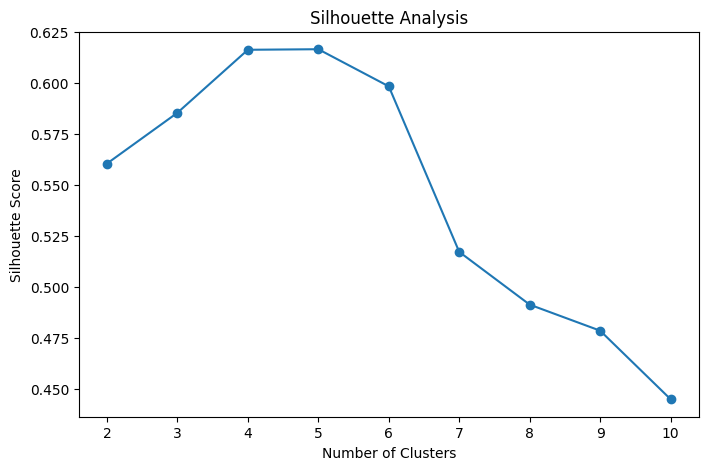

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [25]:
cluster_summary = rfm.groupby(
    'Cluster'
)[['Recency',
   'Frequency',
   'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [26]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

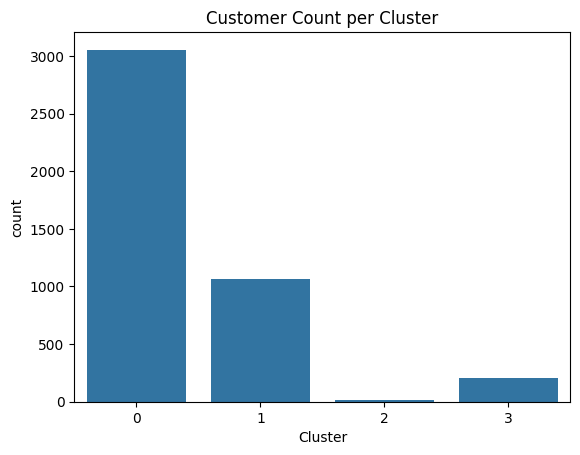

In [27]:
sns.countplot(
    x='Cluster',
    data=rfm
)

plt.title("Customer Count per Cluster")

plt.show()

In [56]:
cluster_names = {

    0:'Occasional',
    1:'At Risk',
    2:'High Value',
    3:'Regular'

}

In [57]:
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

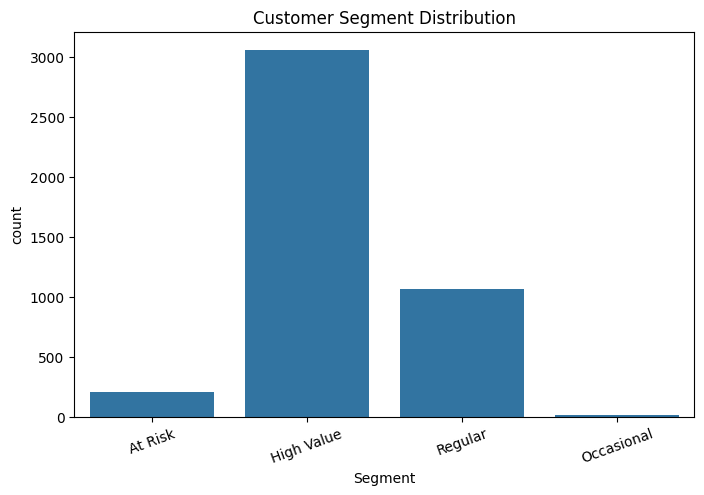

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=rfm
)

plt.title(
    "Customer Segment Distribution"
)

plt.xticks(rotation=20)

plt.show()

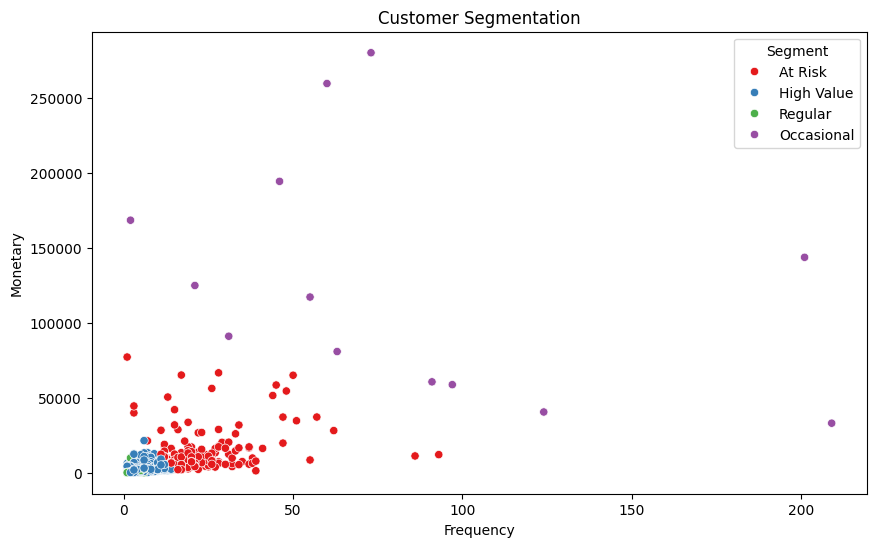

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=rfm,

    x='Frequency',

    y='Monetary',

    hue='Segment',

    palette='Set1'

)

plt.title(
    "Customer Segmentation"
)

plt.show()

In [32]:
from mpl_toolkits.mplot3d import Axes3D

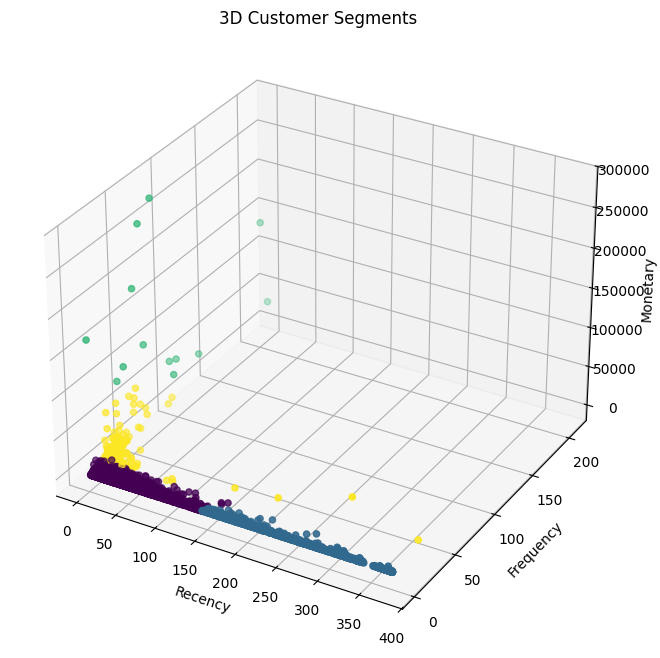

In [33]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(

    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],

    c=rfm['Cluster']

)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segments")

plt.show()

In [34]:
customer_product = pd.crosstab(

    df['CustomerID'],
    df['Description']

)

In [35]:
product_similarity = cosine_similarity(
    customer_product.T
)

In [36]:
similarity_df = pd.DataFrame(

    product_similarity,

    index=customer_product.columns,

    columns=customer_product.columns

)

In [37]:
def recommend_product(product_name):

    product_name = product_name.upper()

    if product_name not in similarity_df.columns:

        return "Product Not Found"

    recommendations = (

        similarity_df[product_name]

        .sort_values(
            ascending=False
        )

        .iloc[1:6]

    )

    return recommendations.index.tolist()

In [38]:
recommend_product(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

['RED HANGING HEART T-LIGHT HOLDER',
 'CANDLEHOLDER PINK HANGING HEART',
 'WOODEN PICTURE FRAME WHITE FINISH',
 'WOODEN FRAME ANTIQUE WHITE ',
 'HEART OF WICKER LARGE']

In [39]:
top_products = similarity_df.iloc[
    :20,
    :20
]

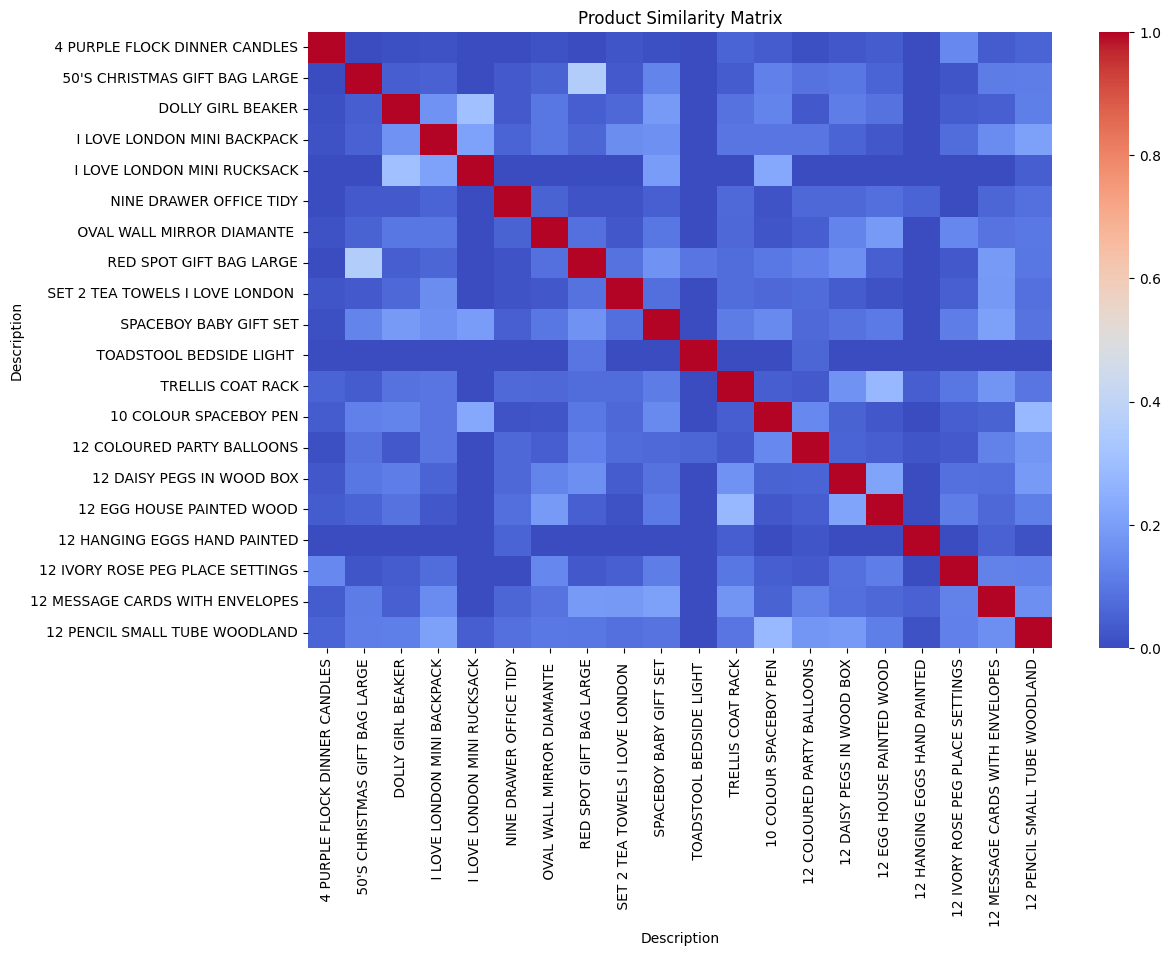

In [40]:
plt.figure(figsize=(12,8))

sns.heatmap(
    top_products,
    cmap='coolwarm'
)

plt.title(
    "Product Similarity Matrix"
)

plt.show()

In [41]:
joblib.dump(
    kmeans,
    'kmeans_model.pkl'
)

['kmeans_model.pkl']

In [42]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

In [43]:
joblib.dump(
    similarity_df,
    'product_similarity.pkl'
)

['product_similarity.pkl']

In [44]:
rfm.to_csv(
    "customer_segments.csv",
    index=False
)

In [45]:
final_silhouette = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print(
    "Silhouette Score:",
    round(final_silhouette,4)
)

Silhouette Score: 0.6162


# Product Recommendation System

In [46]:
customer_product = pd.crosstab(
    df['CustomerID'],
    df['Description']
)

In [47]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    customer_product.T
)

In [48]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

In [49]:
def recommend_product(product_name):

    product_name = product_name.upper()

    if product_name not in similarity_df.columns:
        return "Product Not Found"

    recommendations = (
        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:6]
    )

    return recommendations.index.tolist()

In [50]:
df['Description'].value_counts().head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
LUNCH BAG RED RETROSPOT               1303
SET OF 3 CAKE TINS PANTRY DESIGN      1152
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1078
PACK OF 72 RETROSPOT CAKE CASES       1050
SPOTTY BUNTING                        1014
PAPER CHAIN KIT 50'S CHRISTMAS        1003
LUNCH BAG SPACEBOY DESIGN              993
HEART OF WICKER SMALL                  979
LUNCH BAG CARS BLUE                    977
NATURAL SLATE HEART CHALKBOARD         972
LUNCH BAG PINK POLKADOT                941
LUNCH BAG SUKI DESIGN                  915
REX CASH+CARRY JUMBO SHOPPER           897
ALARM CLOCK BAKELIKE RED               886
Name: count, dtype: int64

In [51]:
recommend_product(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

['RED HANGING HEART T-LIGHT HOLDER',
 'CANDLEHOLDER PINK HANGING HEART',
 'WOODEN PICTURE FRAME WHITE FINISH',
 'WOODEN FRAME ANTIQUE WHITE ',
 'HEART OF WICKER LARGE']

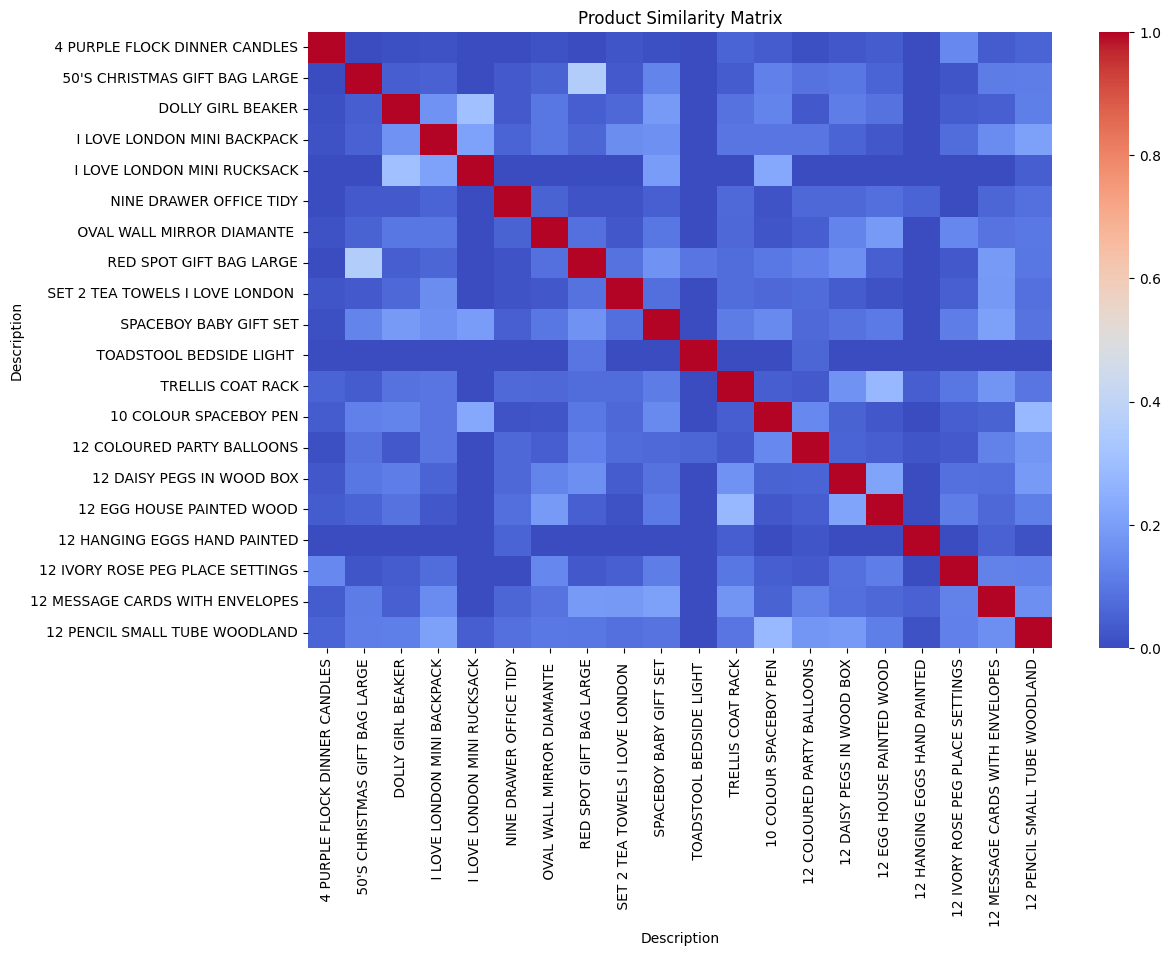

In [52]:
top_products = similarity_df.iloc[:20,:20]

plt.figure(figsize=(12,8))

sns.heatmap(
    top_products,
    cmap='coolwarm'
)

plt.title(
    'Product Similarity Matrix'
)

plt.show()

In [53]:
import joblib

joblib.dump(
    similarity_df,
    "models/product_similarity.pkl"
)

['models/product_similarity.pkl']

In [54]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [55]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [ ]:
df['Description'].value_counts().head(20)